In [15]:
import sys
from pathlib import Path
import pandas as pd
from diff_diff.utils import check_parallel_trends
import matplotlib.pyplot as plt
from diff_diff.utils import check_parallel_trends, check_parallel_trends_robust, equivalence_test_trends
import importlib
import parallel_trends
importlib.reload(parallel_trends)
from parallel_trends import plot_trends_staggered

# adjust the relative path based on where the notebook actually sits
sys.path.append(str(Path.cwd().parent / "src"))

from parallel_trends import plot_dose_trends

In [16]:
df = pd.read_csv("../data/simulated/continuous_did_simulated.csv")

df.head()

,unit,period,outcome,first_treat,dose,true_att
0,0,1,1.597979,0,0.0,0.0
1,0,2,2.732530,0,0.0,0.0
2,0,3,3.867351,0,0.0,0.0
3,0,4,1.900560,0,0.0,0.0
4,0,5,4.962758,0,0.0,0.0


In [17]:

# static ever-treated dummy for the simple binary check
df["ever_treated"] = (df["first_treat"] != 0).astype(int)

results_pt_actual = check_parallel_trends(
    df,
    outcome="outcome",
    time="period",
    treatment_group="ever_treated",
    pre_periods=[1, 2],   # only periods common to both cohorts pre-treatment
)

print(f"Treated trend: {results_pt_actual['treated_trend']:.4f}")
print(f"Control trend: {results_pt_actual['control_trend']:.4f}")
print(f"Difference: {results_pt_actual['trend_difference']:.4f}  p={results_pt_actual['p_value']:.4f}")
print(f"Parallel trends plausible: {results_pt_actual['parallel_trends_plausible']}")

Treated trend: 0.5063
Control trend: 0.5651
Difference: -0.0587  p=0.7910
Parallel trends plausible: True


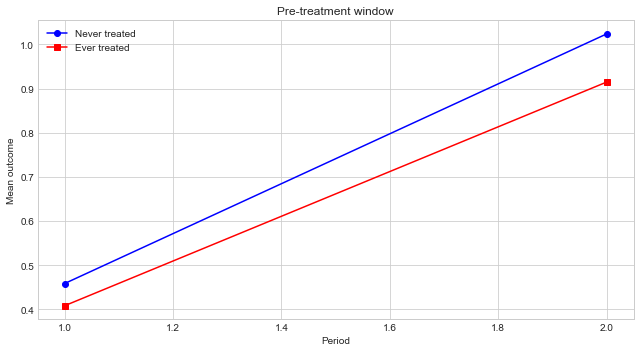

In [18]:
df["ever_treated"] = (df["first_treat"] != 0).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
plot_trends_staggered(df, "Pre-treatment window", ax, pre_periods=[1, 2])
plt.tight_layout()
plt.show()

In [19]:
from diff_diff import ContinuousDiD

est = ContinuousDiD(seed=42)
results = est.fit(
    df,
    outcome="outcome",
    unit="unit",
    time="period",
    first_treat="first_treat",
    dose="dose",
)
print(results.summary())

                     Continuous Difference-in-Differences Results                    
                      (Callaway, Goodman-Bacon & Sant'Anna 2024)                     

Total observations:                  8000
Treated units:                        700
Control units:                        300
Treatment cohorts:                      2
Time periods:                           8
Control group:                 never_treated
Treatment type:                continuous
B-spline degree:                        3
Interior knots:                         0
Base period:                      varying
Anticipation:                           0

-------------------------------------------------------------------------------------
                              Overall Summary Parameters                             
-------------------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|   Sig.
--------------------------------

In [20]:
treated_doses = df.loc[df["first_treat"] != 0, "dose"]

true_att_glob = 1.0 + 2.0 * treated_doses.mean()
true_acrt_glob = 2.0

print("Parameter comparison:")
print(f"  ATT_glob  — estimated: {results.overall_att:.4f}, true: {true_att_glob:.4f}, "
      f"bias: {results.overall_att - true_att_glob:.4f}")
print(f"  ACRT_glob — estimated: {results.overall_acrt:.4f}, true: {true_acrt_glob:.4f}, "
      f"bias: {results.overall_acrt - true_acrt_glob:.4f}")

Parameter comparison:
  ATT_glob  — estimated: 4.6625, true: 4.6534, bias: 0.0091
  ACRT_glob — estimated: 1.9378, true: 2.0000, bias: -0.0622


# # School Finance DataSet

In [21]:
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from diff_diff import ContinuousDiD
from diff_diff.utils import (
    check_parallel_trends,
    check_parallel_trends_robust,
    equivalence_test_trends,
)

plt.style.use('seaborn-v0_8-whitegrid')

In [22]:
PANEL_INPUT = r"C:\Users\HP\Documents\continuous_DiD\data\real\WA_schoolfinance_graduation_panel.csv"
DOSE_INPUT = r"C:\Users\HP\Documents\continuous_DiD\data\real\continuous_did_panel_short.csv"

DOSE_YEAR = 2016
FIRST_TREAT = 2018  # EHB 2242 full funding phase-in year; 2017 excluded as transition
PRE_PERIODS = [2014, 2016]  # both pre-treatment, used for PT diagnostics

def normalize_name(name):
    if pd.isna(name):
        return ""
    n = str(name).lower()
    n = re.sub(r"[^a-z0-9 ]", " ", n)
    n = re.sub(r"\bschool district\b", "", n)
    n = re.sub(r"\bschool dist\b", "", n)
    n = re.sub(r"\bpublic schools\b", "", n)
    n = re.sub(r"\bsd\b", "", n)
    n = re.sub(r"\bno\b", "", n)
    n = re.sub(r"\d+", "", n)
    n = re.sub(r"\s+", " ", n).strip()
    return n

# Outcome panel -- already built, just load it
panel = pd.read_csv(PANEL_INPUT)
panel["name_key"] = panel["districtname"].apply(normalize_name)

# Dose -- already built and saved (2016 local revenue per pupil, IQR-trimmed).
# No need to re-read the raw F-33 files -- just pull the dose column straight
# from the collapsed panel you already produced.
dose_df = pd.read_csv(DOSE_INPUT)[["name_key", "dose"]].drop_duplicates("name_key")

print("Districts with dose:", len(dose_df))
print("Years already in panel:", sorted(panel['YEAR'].unique().tolist()))

Districts with dose: 203
Years already in panel: [2016, 2017, 2018, 2019, 2020, 2021, 2022]


In [23]:
GRAD_2014_PATH = r"C:\Users\HP\Documents\continuous_DiD\data\ospi_graduation\graduation_2014_15.csv"

grad_2014 = pd.read_csv(GRAD_2014_PATH, low_memory=False)
grad_2014 = grad_2014[grad_2014["organizationlevel"] == "District"].copy()
grad_2014["name_key"] = grad_2014["districtname"].apply(normalize_name)
grad_2014 = (
    grad_2014.groupby("name_key", as_index=False)
    .agg(graduationrate=("graduationrate", "mean"))
)
grad_2014["YEAR"] = 2014

# Only add columns pre-trend cells need; other panel columns stay NaN for these rows,
# which is fine since we only ever filter panel down to YEAR + name_key + graduationrate.
panel_with_2014 = pd.concat(
    [panel[["name_key", "YEAR", "graduationrate"]], grad_2014[["name_key", "YEAR", "graduationrate"]]],
    ignore_index=True,
)

print("2014 graduation rows added:", len(grad_2014))
print("Years now available for diagnostics:", sorted(panel_with_2014['YEAR'].unique().tolist()))

2014 graduation rows added: 258
Years now available for diagnostics: [2014, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


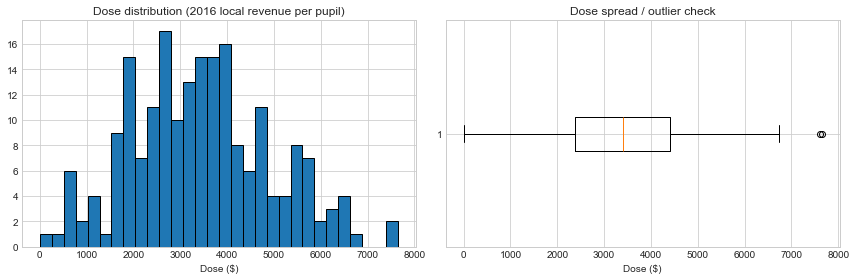

count     203.000000
mean     3442.333528
std      1492.538478
min         0.000000
25%      2368.524049
50%      3396.116505
75%      4408.916646
max      7648.089888
Name: dose, dtype: float64

Overlap check -- observations per decile:
dose
(-0.001, 1726.647]      21
(1726.647, 2106.511]    20
(2106.511, 2627.909]    20
(2627.909, 3003.339]    20
(3003.339, 3396.117]    21
(3396.117, 3716.432]    20
(3716.432, 4059.36]     20
(4059.36, 4681.631]     20
(4681.631, 5492.492]    20
(5492.492, 7648.09]     21
Name: count, dtype: int64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dose_df["dose"], bins=30, edgecolor="black")
axes[0].set_title("Dose distribution (2016 local revenue per pupil)")
axes[0].set_xlabel("Dose ($)")

axes[1].boxplot(dose_df["dose"], vert=False)
axes[1].set_title("Dose spread / outlier check")
axes[1].set_xlabel("Dose ($)")
plt.tight_layout()
plt.show()

print(dose_df["dose"].describe())
print("\nOverlap check -- observations per decile:")
print(pd.qcut(dose_df["dose"], 10, duplicates="drop").value_counts().sort_index())

In [25]:
dose_df["dose_quartile"] = pd.qcut(dose_df["dose"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
print(dose_df["dose_quartile"].value_counts().sort_index())

dose_quartile
Q1 (lowest)     51
Q2              51
Q3              50
Q4 (highest)    51
Name: count, dtype: int64


In [26]:
#Discretize the continuous dose into deciles for the main analysis. This is a common approach in continuous DiD to ensure that each unit within a bin has the same treatment value, which simplifies interpretation and estimation.
N_DOSE_BINS = 10  # deciles -- matches the overlap check already run in Stage 1a

dose_df["dose_decile"] = pd.qcut(dose_df["dose"], N_DOSE_BINS, duplicates="drop")
# Use each decile's mean dose as the discrete dose VALUE -- keeps real economic
# magnitude (dollars) while giving every unit in a bin the exact same tied value.
dose_df["dose_discrete"] = dose_df.groupby("dose_decile")["dose"].transform("mean")

print("Districts per discrete dose level (mass points):")
print(dose_df["dose_discrete"].value_counts().sort_index())
print(f"\nLowest dose level: {dose_df['dose_discrete'].min():,.2f} "
      f"({(dose_df['dose_discrete'] == dose_df['dose_discrete'].min()).sum()} units -- "
      f"this is the mass point control_group='lowest_dose' needs)")

Districts per discrete dose level (mass points):
dose_discrete
1030.808393    21
1910.115181    20
2377.984764    20
2795.317760    20
3204.990792    21
3575.386130    20
3896.202250    20
4371.647796    20
5068.346695    20
6187.710080    21
Name: count, dtype: int64

Lowest dose level: 1,030.81 (21 units -- this is the mass point control_group='lowest_dose' needs)


C:\Users\HP\AppData\Local\Temp\ipykernel_1380\1329483044.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dose_df["dose_discrete"] = dose_df.groupby("dose_decile")["dose"].transform("mean")


In [27]:
#Anticipation Window.
ANTICIPATION = 0  # documented choice -- see markdown above

In [28]:
#Assessing identifying assumptions for continuous DiD is crucial. The parallel trends assumption, in particular, must be evaluated to ensure that the treatment effect estimates are valid. This involves checking whether the treated and control groups would have followed similar trends in the absence of treatment.
pt_check_data = panel_with_2014[panel_with_2014["YEAR"].isin(PRE_PERIODS)][["name_key", "YEAR", "graduationrate"]].rename(
    columns={"YEAR": "period", "graduationrate": "outcome"}
)
pt_check_data = pt_check_data.merge(
    dose_df[dose_df["dose_quartile"].isin(["Q1 (lowest)", "Q4 (highest)"])][["name_key", "dose_quartile"]],
    on="name_key", how="inner",
)
pt_check_data["treated"] = (pt_check_data["dose_quartile"] == "Q4 (highest)").astype(int)
pt_check_data = pt_check_data.rename(columns={"name_key": "unit"})

# Balance: need both pre-periods for each unit
counts = pt_check_data.groupby("unit")["period"].nunique()
balanced = counts[counts == len(PRE_PERIODS)].index
pt_check_data = pt_check_data[pt_check_data["unit"].isin(balanced)].copy()

print("Q1 vs Q4 districts in PT check:", pt_check_data.groupby("treated")["unit"].nunique().to_dict())

Q1 vs Q4 districts in PT check: {0: 51, 1: 51}


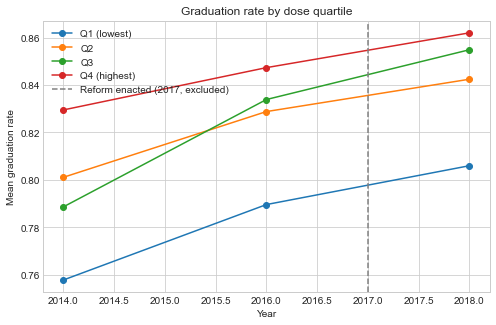

In [29]:
#Visual Inspection of dose quartiles over time can provide an initial sense of whether the parallel trends assumption holds. If the trends for the treated and control groups are similar in the pre-treatment periods, it lends support to the validity of the DiD approach. 
viz_data = panel_with_2014[panel_with_2014["YEAR"].isin(PRE_PERIODS + [FIRST_TREAT])][["name_key", "YEAR", "graduationrate"]]
viz_data = viz_data.merge(dose_df[["name_key", "dose_quartile"]], on="name_key", how="inner")

means = viz_data.groupby(["YEAR", "dose_quartile"], observed=True)["graduationrate"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
for col in means.columns:
    ax.plot(means.index, means[col], "o-", label=col)
ax.axvline(x=2017, color="gray", linestyle="--", label="Reform enacted (2017, excluded)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean graduation rate")
ax.set_title("Graduation rate by dose quartile")
ax.legend()
plt.show()

In [30]:
#Standart Parallel Trends Check: The standard parallel trends check involves estimating the pre-treatment trends for the treated and control groups and testing whether these trends are statistically different. This can be done using regression models that include interaction terms between time and treatment indicators, allowing for a formal statistical test of the parallel trends assumption.
pt_results = check_parallel_trends(
    pt_check_data,
    outcome="outcome",
    time="period",
    treatment_group="treated",
    pre_periods=PRE_PERIODS,
)

print("Standard PT test (Q1 vs Q4):")
print(f"  Treated (Q4) trend: {pt_results['treated_trend']:.4f}")
print(f"  Control (Q1) trend: {pt_results['control_trend']:.4f}")
print(f"  Difference: {pt_results['trend_difference']:.4f}  p={pt_results['p_value']:.4f}")
print(f"  PT plausible: {pt_results['parallel_trends_plausible']}")

Standard PT test (Q1 vs Q4):
  Treated (Q4) trend: nan
  Control (Q1) trend: nan
  Difference: nan  p=nan
  PT plausible: None


In [31]:
#Robust Parallel Trends Check: The robust parallel trends check extends the standard approach by allowing for more flexible specifications of the pre-treatment trends. This can include using polynomial terms or other functional forms to capture potential non-linearities in the trends, providing a more comprehensive assessment of the parallel trends assumption.
pt_robust_results = check_parallel_trends_robust(
    pt_check_data,
    outcome="outcome",
    time="period",
    treatment_group="treated",
    unit="unit",
    pre_periods=PRE_PERIODS,
    n_permutations=999,
    seed=42,
)

print("Robust PT test (Q1 vs Q4):")
print(f"  Wasserstein distance: {pt_robust_results['wasserstein_distance']:.4f}")
print(f"  Wasserstein p-value: {pt_robust_results['wasserstein_p_value']:.4f}")
print(f"  KS p-value: {pt_robust_results['ks_p_value']:.4f}")
print(f"  PT plausible: {pt_robust_results['parallel_trends_plausible']}")

Robust PT test (Q1 vs Q4):
  Wasserstein distance: 0.0236
  Wasserstein p-value: 0.0480
  KS p-value: 0.3959
  PT plausible: False


C:\Users\HP\AppData\Local\Temp\ipykernel_1380\1236998517.py:2: UserWarning: check_parallel_trends_robust: dropped 104 row(s) with NaN first-differences; 102 are the expected first-period-per-unit drops, and 2 are additional NaN first-differences (e.g. NaN outcomes or unit-period gaps upstream). Parallel-trend statistics are computed on the remaining rows.
  pt_robust_results = check_parallel_trends_robust(


In [32]:
# TOST
EQUIVALENCE_MARGIN = 0.02

tost_results = equivalence_test_trends(
    pt_check_data,
    outcome="outcome",
    time="period",
    treatment_group="treated",
    unit="unit",
    pre_periods=PRE_PERIODS,
    equivalence_margin=EQUIVALENCE_MARGIN,
)

print("TOST equivalence test (Q1 vs Q4):")
print(f"  Mean difference: {tost_results['mean_difference']:.4f}")
print(f"  Equivalence margin: +/- {EQUIVALENCE_MARGIN}")
print(f"  TOST p-value: {tost_results['tost_p_value']:.4f}")
print(f"  Trends practically equivalent: {tost_results['equivalent']}")

TOST equivalence test (Q1 vs Q4):
  Mean difference: -0.0132
  Equivalence margin: +/- 0.02
  TOST p-value: 0.2697
  Trends practically equivalent: False


C:\Users\HP\AppData\Local\Temp\ipykernel_1380\3139059028.py:4: UserWarning: equivalence_test_trends: dropped 104 row(s) with NaN first-differences; 102 are the expected first-period-per-unit drops, and 2 are additional NaN first-differences (e.g. NaN outcomes or unit-period gaps upstream). Parallel-trend statistics are computed on the remaining rows.
  tost_results = equivalence_test_trends(


In [33]:
#Summary of Parallel Trends Diagnostics: After conducting the standard, robust, and TOST parallel trends checks, it's important to summarize the findings. If all tests suggest that the pre-treatment trends are similar between the treated and control groups, it strengthens the credibility of the DiD estimates. Conversely, if any test indicates significant differences in trends, caution should be exercised in interpreting the results, and alternative identification strategies may need to be considered.

summary_table = pd.DataFrame([
    {"Test": "Standard PT", "p_value": pt_results["p_value"],
     "Result": "Pass" if pt_results["parallel_trends_plausible"] else "Fail",
     "Interpretation": "No evidence against PT" if pt_results["parallel_trends_plausible"] else "Evidence against PT"},
    {"Test": "Robust PT (Wasserstein)", "p_value": pt_robust_results["wasserstein_p_value"],
     "Result": "Pass" if pt_robust_results["parallel_trends_plausible"] else "Fail",
     "Interpretation": "Distributional PT plausible" if pt_robust_results["parallel_trends_plausible"] else "Distributional violation detected"},
    {"Test": "TOST", "p_value": tost_results["tost_p_value"],
     "Result": "Pass" if tost_results["equivalent"] else "Fail",
     "Interpretation": "Trends practically equivalent" if tost_results["equivalent"] else "Cannot confirm practical equivalence"},
])
summary_table

,Test,p_value,Result,Interpretation
0,Standard PT,NaN,Fail,Evidence against PT
1,Robust PT (Wasserstein),0.048048,Fail,Distributional violation detected
2,TOST,0.269736,Fail,Cannot confirm practical equivalence


In [34]:
# Continuous Pre-trend Checks 
# Extend did_data (built in Stage 3) to include 2014, using the same dose
# and the same first_treat. This uses every district's actual dose value,
# not just Q1/Q4 -- the full continuous distribution.

pretrend_data = pd.concat(
    [
        panel[["name_key", "YEAR", "graduationrate"]].rename(
            columns={"name_key": "unit", "YEAR": "time", "graduationrate": "outcome"}
        ),
        grad_2014.rename(columns={"name_key": "unit", "YEAR": "time", "graduationrate": "outcome"}),
    ],
    ignore_index=True,
)
pretrend_data = pretrend_data.merge(
    dose_df[["name_key", "dose_discrete"]].rename(columns={"name_key": "unit", "dose_discrete": "dose"}), on="unit", how="inner"
)
pretrend_data["first_treat"] = FIRST_TREAT

# Balance: keep only units present in every year now available (2014 + panel years)
years_present_pt = sorted(pretrend_data["time"].unique())
counts_pt = pretrend_data.groupby("unit")["time"].nunique()
balanced_pt = counts_pt[counts_pt == len(years_present_pt)].index
pretrend_data = pretrend_data[pretrend_data["unit"].isin(balanced_pt)].copy()

print("Years used for pre-trend event study:", years_present_pt)
print("Balanced districts:", pretrend_data["unit"].nunique())

Years used for pre-trend event study: [2014, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Balanced districts: 203


In [38]:
# 1. Clean pretrend_data first (from the previous message)
pretrend_data = pretrend_data.dropna(subset=["outcome", "dose"])
pretrend_data = pretrend_data[np.isfinite(pretrend_data["outcome"])]
years_present_pt = sorted(pretrend_data["time"].unique())
counts_pt = pretrend_data.groupby("unit")["time"].nunique()
balanced_pt = counts_pt[counts_pt == len(years_present_pt)].index
pretrend_data = pretrend_data[pretrend_data["unit"].isin(balanced_pt)].copy()
print("pretrend_data balanced districts after cleaning:", pretrend_data["unit"].nunique())

# 2. Now fit -- this is your code, uncommented
pretrend_est = ContinuousDiD(
    control_group="lowest_dose",
    treatment_type="discrete",
    anticipation=ANTICIPATION,
    n_bootstrap=0,   # analytical inference -- required for post-fit aggregate('event_study')
    seed=42,
)

pretrend_results = pretrend_est.fit(
    pretrend_data,
    outcome="outcome",
    unit="unit",
    time="time",
    first_treat="first_treat",
    dose="dose",
)

pretrend_event_study = pretrend_results.aggregate('event_study')
pretrend_es_df = pretrend_event_study.to_dataframe()
print(pretrend_es_df)

pretrend_data balanced districts after cleaning: 187
   event_time       att        se    t_stat   p_value  conf_int_lower  \
0          -2 -0.020797  0.013991 -1.486437  0.137164       -0.048219   
1          -1 -0.000534  0.007303 -0.073155  0.941683       -0.014847   
2           0  0.002118  0.005692  0.372167  0.709769       -0.009037   
3           1 -0.005038  0.007785 -0.647148  0.517536       -0.020296   
4           2 -0.012423  0.008980 -1.383368  0.166552       -0.030024   
5           3 -0.008541  0.013015 -0.656245  0.511667       -0.034050   
6           4 -0.007191  0.013977 -0.514487  0.606912       -0.034586   

   conf_int_upper  cband_lower  cband_upper   n  df  is_reference estimand  
0        0.006625          NaN          NaN NaN NaN         False      att  
1        0.013779          NaN          NaN NaN NaN         False      att  
2        0.013274          NaN          NaN NaN NaN         False      att  
3        0.010220          NaN          NaN NaN NaN   

In [39]:
pretrend_results = pretrend_est.fit(
    pretrend_data,
    outcome="outcome",
    unit="unit",
    time="time",
    first_treat="first_treat",
    dose="dose",
    aggregate="eventstudy",   # compute at fit-time, keeps bootstrap SEs
)

C:\Users\HP\AppData\Local\Temp\ipykernel_1380\1222552285.py:1: FutureWarning: ContinuousDiD.fit(aggregate=) is deprecated and will be removed in 4.0. Fit once, then aggregate as a post-fit step: results = ContinuousDiD().fit(...); results.aggregate('event_study') (note the underscore - the 'eventstudy' spelling dies with this parameter) / .aggregate('dose') / .aggregate('simple'). The dose-response curves and overall ATT/ACRT are always computed by fit(), so aggregate='dose' was already redundant.
  pretrend_results = pretrend_est.fit(


Pre-treatment event-time estimates (should be ~0, non-significant if PT holds):
   event_time       att        se    t_stat   p_value  conf_int_lower  \
0          -2 -0.020797  0.013991 -1.486437  0.137164       -0.048219   
1          -1 -0.000534  0.007303 -0.073155  0.941683       -0.014847   

   conf_int_upper  cband_lower  cband_upper   n  df  is_reference estimand  
0        0.006625          NaN          NaN NaN NaN         False      att  
1        0.013779          NaN          NaN NaN NaN         False      att  


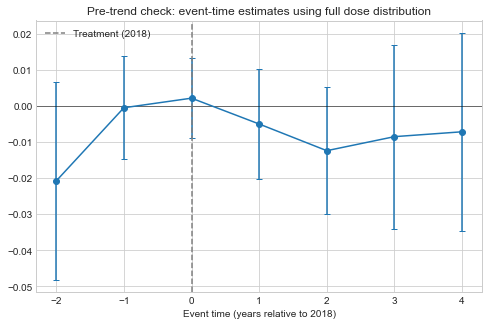


Any significant pre-treatment estimate (p<0.05): False


In [41]:
event_time_col = pretrend_es_df.columns[0]
pre_treatment_rows = pretrend_es_df[pretrend_es_df[event_time_col] < 0]

print("Pre-treatment event-time estimates (should be ~0, non-significant if PT holds):")
print(pre_treatment_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(pretrend_es_df[event_time_col], pretrend_es_df["att"],
            yerr=1.96*pretrend_es_df["se"], fmt="o-", capsize=3)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="gray", linestyle="--", label="Treatment (2018)")
ax.set_title("Pre-trend check: event-time estimates using full dose distribution")
ax.set_xlabel("Event time (years relative to 2018)")
ax.legend()
plt.show()

any_significant_pretrend = (pre_treatment_rows["p_value"] < 0.05).any() if "p_value" in pre_treatment_rows.columns else None
print(f"\nAny significant pre-treatment estimate (p<0.05): {any_significant_pretrend}")